In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O

# Input data files are available in the read-only
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/archive-zip/coqa-dev-v1.0.json
/kaggle/input/archive-zip/coqa-train-v1.0.json


In [3]:
import os
print(os.listdir("/kaggle/input"))


['archive-zip']


In [4]:
from pathlib import Path
import json

data_dir = Path("/kaggle/input/archive-zip")
print("Files in data_dir:", [p.name for p in data_dir.iterdir()])

train_path = data_dir / "coqa-train-v1.0.json"
dev_path   = data_dir / "coqa-dev-v1.0.json"

with open(train_path, "r") as f:
    train_data = json.load(f)

with open(dev_path, "r") as f:
    dev_data = json.load(f)

print(type(train_data), train_data.keys())
print("Train stories:", len(train_data.get("data", [])))
print("Dev stories:", len(dev_data.get("data", [])))


Files in data_dir: ['coqa-dev-v1.0.json', 'coqa-train-v1.0.json']
<class 'dict'> dict_keys(['version', 'data'])
Train stories: 7199
Dev stories: 500


In [5]:
import pandas as pd

def coqa_to_rows(coqa_split, split_name="train"):
    rows = []
    for story in coqa_split.get("data", []):
        story_id = story.get("id")
        context  = story.get("story")
        questions = story.get("questions", [])
        answers   = story.get("answers", [])
        for q, a in zip(questions, answers):
            rows.append({
                "split": split_name,
                "story_id": story_id,
                "context": context,
                "question_id": q.get("turn_id"),
                "question": q.get("input_text"),
                "answer": a.get("input_text")
            })
    return rows

train_rows = coqa_to_rows(train_data, split_name="train")
dev_rows   = coqa_to_rows(dev_data, split_name="dev")

qa_df = pd.DataFrame(train_rows + dev_rows)
print(qa_df.shape)
print(qa_df.columns)
qa_df.head()


(116630, 6)
Index(['split', 'story_id', 'context', 'question_id', 'question', 'answer'], dtype='object')


,split,story_id,context,question_id,question,answer
0,train,3zotghdk5ibi9cex97fepx7jetpso7,"The Vatican Apostolic Library (), more commonl...",1,When was the Vat formally opened?,It was formally established in 1475
1,train,3zotghdk5ibi9cex97fepx7jetpso7,"The Vatican Apostolic Library (), more commonl...",2,what is the library for?,research
2,train,3zotghdk5ibi9cex97fepx7jetpso7,"The Vatican Apostolic Library (), more commonl...",3,for what subjects?,"history, and law"
3,train,3zotghdk5ibi9cex97fepx7jetpso7,"The Vatican Apostolic Library (), more commonl...",4,and?,"philosophy, science and theology"
4,train,3zotghdk5ibi9cex97fepx7jetpso7,"The Vatican Apostolic Library (), more commonl...",5,what was started in 2014?,a project


In [6]:
qa_df.sample(3)[["split", "story_id", "question", "answer"]]


,split,story_id,question,answer
43818,train,3l4d84milzsfis9ki0badnjv5b4jh9,Who was Anderson Rover?,unknown
63912,train,3mrnmeiqw56412sizp4x2hhpii9ldi,What alternative budget was introduced?,One that balances the federal budget in four y...
90861,train,3qilpralq5vi87zcuu9wth7dchv8na,Who is thinking about it in the UK?,Gordon Brown


In [8]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer, util
import torch


In [9]:
# small subset for initial experiments
small_df = qa_df.sample(500, random_state=42).reset_index(drop=True)
small_df.shape


(500, 6)

In [10]:
model = SentenceTransformer("all-MiniLM-L6-v2")  # light, fast model [web:52]

contexts = small_df["context"].tolist()
context_embeddings = model.encode(contexts, convert_to_tensor=True, show_progress_bar=True)
context_embeddings.shape


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

torch.Size([500, 384])

In [12]:
def answer_question_simple(question, k=3):
    # encode question
    q_emb = model.encode(question, convert_to_tensor=True)
    
    # cosine similarity with all contexts
    cos_scores = util.pytorch_cos_sim(q_emb, context_embeddings)[0]
    
    # top-k indices
    topk = torch.topk(cos_scores, k)
    indices = topk.indices.cpu().tolist()
    scores  = topk.values.cpu().tolist()
    
    results = []
    for rank, (idx, score) in enumerate(zip(indices, scores), start=1):
        row = small_df.iloc[idx]
        results.append({
            "rank": rank,
            "score": float(score),
            "context": row["context"],
            "question": row["question"],
            "gold_answer": row["answer"]
        })
    return results


In [13]:
sample_row = small_df.iloc[0]
print("Original question:", sample_row["question"])
print("Gold answer:", sample_row["answer"])

results = answer_question_simple(sample_row["question"], k=3)
for r in results:
    print("\nRank", r["rank"], "score", round(r["score"], 3))
    print("Context snippet:", r["context"][:200].replace("\n", " "))
    print("Gold answer in that row:", r["gold_answer"])


Original question: Why does Elsie like tracking flights?
Gold answer: she lives near the airport

Rank 1 score 0.55
Context snippet: Elsie Comer is nearly 92, but she can still play a game of Words with Friends on her iPad and claims that the Apple product has changed her life. Mrs. Comer, who lives in a house close to Manchester A
Gold answer in that row: she lives near the airport

Rank 2 score 0.329
Context snippet: One of Britain's bravest women told yesterday how she helped to catch suspected police killer David Bieber--and was thanked with flowers by the police. It was also said that she could _ a share of up 
Gold answer in that row: her bedroom

Rank 3 score 0.312
Context snippet: (CNN) -- When Sadegh Shahi heard reports about a SWAT team armed to the teeth storming onto a Sunwing Airlines flight to arrest a passenger, he thought to himself, "it's probably my son."   The father
Gold answer in that row: No


In [14]:
def hits_at_1(row):
    q = row["question"]
    gold = str(row["answer"]).lower()
    results = answer_question_simple(q, k=1)
    top = results[0]
    context_text = top["context"].lower()
    return int(gold in context_text)

# quick sample evaluation
sample_eval = small_df.head(100).copy()
sample_eval["hit1"] = sample_eval.apply(hits_at_1, axis=1)
sample_eval["hit1"].mean()


np.float64(0.27)

In [15]:
def em_at_1(row):
    q = row["question"]
    gold = str(row["answer"]).strip().lower()
    results = answer_question_simple(q, k=1)
    pred_gold = str(results[0]["gold_answer"]).strip().lower()
    return int(gold == pred_gold)

sample_eval["em1"] = sample_eval.apply(em_at_1, axis=1)
sample_eval[["hit1", "em1"]].mean()


hit1    0.27
em1     0.25
dtype: float64

In [16]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [17]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer, CrossEncoder, util
import torch


In [18]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")  # small but effective reranker


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [24]:
def answer_question_rerank(question, k_retrieve=10, k_final=3):
    # 1) dense retrieval 
    q_emb = model.encode(question, convert_to_tensor=True)
    cos_scores = util.pytorch_cos_sim(q_emb, context_embeddings)[0]
    topk = torch.topk(cos_scores, k_retrieve)
    indices = topk.indices.cpu().tolist()
    
    # 2) build (question, context) pairs
    pairs = []
    rows = []
    for idx in indices:
        row = small_df.iloc[idx]
        pairs.append((question, row["context"]))
        rows.append(row)
    
    # 3) rerank with cross-encoder
    scores = reranker.predict(pairs)  # higher = more relevant
    scored = list(zip(rows, scores))
    scored.sort(key=lambda x: x[1], reverse=True)
    
    # 4) return top k_final after reranking
    results = []
    for rank, (row, score) in enumerate(scored[:k_final], start=1):
        results.append({
            "rank": rank,
            "rerank_score": float(score),
            "context": row["context"],
            "question": row["question"],
            "gold_answer": row["answer"]
        })
    return results


In [25]:
sample_row = small_df.iloc[0]
q = sample_row["question"]
gold = sample_row["answer"]

print("Question:", q)
print("Gold answer:", gold)

print("\n=== Baseline ===")
base_results = answer_question_simple(q, k=3)
for r in base_results:
    print("\nRank", r["rank"])
    print("Context snippet:", r["context"][:180].replace("\n", " "))
    print("Gold answer in that row:", r["gold_answer"])

print("\n=== Reranked ===")
rr_results = answer_question_rerank(q, k_retrieve=10, k_final=3)
for r in rr_results:
    print("\nRank", r["rank"])
    print("Rerank score:", round(r["rerank_score"], 3))
    print("Context snippet:", r["context"][:180].replace("\n", " "))
    print("Gold answer in that row:", r["gold_answer"])


Question: Why does Elsie like tracking flights?
Gold answer: she lives near the airport

=== Baseline ===

Rank 1
Context snippet: Elsie Comer is nearly 92, but she can still play a game of Words with Friends on her iPad and claims that the Apple product has changed her life. Mrs. Comer, who lives in a house c
Gold answer in that row: she lives near the airport

Rank 2
Context snippet: One of Britain's bravest women told yesterday how she helped to catch suspected police killer David Bieber--and was thanked with flowers by the police. It was also said that she co
Gold answer in that row: her bedroom

Rank 3
Context snippet: (CNN) -- When Sadegh Shahi heard reports about a SWAT team armed to the teeth storming onto a Sunwing Airlines flight to arrest a passenger, he thought to himself, "it's probably m
Gold answer in that row: No

=== Reranked ===

Rank 1
Rerank score: 3.757
Context snippet: Elsie Comer is nearly 92, but she can still play a game of Words with Friends on her iPad and cl

In [26]:
def hits_at_1_rerank(row):
    q = row["question"]
    gold = str(row["answer"]).lower()
    results = answer_question_rerank(q, k_retrieve=10, k_final=1)
    top = results[0]
    context_text = top["context"].lower()
    return int(gold in context_text)

def em_at_1_rerank(row):
    q = row["question"]
    gold = str(row["answer"]).strip().lower()
    results = answer_question_rerank(q, k_retrieve=10, k_final=1)
    pred_gold = str(results[0]["gold_answer"]).strip().lower()
    return int(gold == pred_gold)


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Keep your base dataframe of 100 rows
sample_eval = small_df.head(100).copy()

# Number of bootstrap runs
N_BOOT = 30
rng = np.random.default_rng(42)

def evaluate_split(df):
    """Compute all metrics on a given DataFrame slice."""
    # Recompute metrics for this slice to avoid leakage
    df = df.copy()
    df["hit1_base"] = df.apply(hits_at_1, axis=1)
    df["em1_base"]  = df.apply(em_at_1, axis=1)
    df["hit1_rr"]   = df.apply(hits_at_1_rerank, axis=1)
    df["em1_rr"]    = df.apply(em_at_1_rerank, axis=1)

    # For classification-style metrics we treat:
    #  - y_true: 1 if gold answer appears in gold context (always 1 here, so use Hit@1 signals)
    #  - y_pred: hit1_base / hit1_rr (1 = retrieved passage contains answer, 0 = does not)
    y_true = np.ones(len(df), dtype=int)  # every question should have a correct context somewhere
    y_pred_base = df["hit1_base"].astype(int).to_numpy()
    y_pred_rr   = df["hit1_rr"].astype(int).to_numpy()

    # Avoid zero-division warnings: use 'zero_division=0'
    prec_base = precision_score(y_true, y_pred_base, zero_division=0)
    rec_base  = recall_score(y_true, y_pred_base, zero_division=0)
    f1_base   = f1_score(y_true, y_pred_base, zero_division=0)

    prec_rr = precision_score(y_true, y_pred_rr, zero_division=0)
    rec_rr  = recall_score(y_true, y_pred_rr, zero_division=0)
    f1_rr   = f1_score(y_true, y_pred_rr, zero_division=0)

    return {
        "hit1_base": df["hit1_base"].mean(),
        "hit1_rr":   df["hit1_rr"].mean(),
        "em1_base":  df["em1_base"].mean(),
        "em1_rr":    df["em1_rr"].mean(),
        "prec_base": prec_base,
        "rec_base":  rec_base,
        "f1_base":   f1_base,
        "prec_rr":   prec_rr,
        "rec_rr":    rec_rr,
        "f1_rr":     f1_rr,
    }

# 1) Metrics on the full 100-question set (what you already had, plus new ones)
full_metrics = evaluate_split(sample_eval)
print("Full 100-question metrics:")
for k, v in full_metrics.items():
    print(f"{k:10s}: {v:.3f}")

# 2) Bootstrap over the 100 questions
boot_results = []

indices = np.arange(len(sample_eval))
for _ in range(N_BOOT):
    boot_idx = rng.choice(indices, size=len(indices), replace=True)
    boot_df = sample_eval.iloc[boot_idx]
    boot_results.append(evaluate_split(boot_df))

boot_array = {k: np.array([r[k] for r in boot_results]) for k in boot_results[0].keys()}

print("\nBootstrap means ± std (N_BOOT = %d):" % N_BOOT)
for k, arr in boot_array.items():
    print(f"{k:10s}: {arr.mean():.3f} ± {arr.std():.3f}")


Full 100-question metrics:
hit1_base : 0.270
hit1_rr   : 0.360
em1_base  : 0.250
em1_rr    : 0.310
prec_base : 1.000
rec_base  : 0.270
f1_base   : 0.425
prec_rr   : 1.000
rec_rr    : 0.360
f1_rr     : 0.529


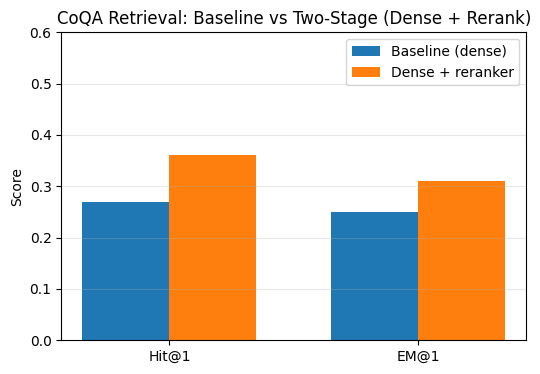

In [4]:
plt.figure(figsize=(6,4))
plt.bar(x - width/2, baseline_scores, width, label="Baseline (dense)")
plt.bar(x + width/2, rerank_scores,   width, label="Dense + reranker")

plt.xticks(x, metrics)
plt.ylim(0, 0.6)  
plt.ylabel("Score")
plt.title("CoQA Retrieval: Baseline vs Two‑Stage (Dense + Rerank)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()
